# Figure 4: Xenium non-small-cell lung cancer

Segmentation mask geometry reshapes the cellular neighbourhood structure.
This notebook reproduces the panels of Fig. 4, starting from the public data.
Segger, Proseg and Baysor are compared against a transcript-independent reference, a Cellpose segmentation of the NaK-ATPase membrane and DAPI image of a Xenium non-small-cell lung cancer (NSCLC) section (383-gene panel).
Segger, Proseg and Baysor received only the transcripts and the DAPI-derived nuclear segmentation.

| | |
|---|---|
| Data | Xenium NSCLC section generated for this study, Cellpose membrane reference, segmentations of all methods; 7.8 GB download |
| Compute | CPU, 24 GB RAM, about 30 min. `segger segment` needs a CUDA GPU. |
| Output | `results/figure_4/panel_{a,b,c,de,f}.{pdf,png}` |

In [1]:
import subprocess
import warnings
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import scanpy as sc

import sg_utils as sg
from sg_utils.pl import fov
from sg_utils.pl.style import MM
from sg_utils.tl import boundaries, celltyping, metrics, neighbors

sg.pl.set_style()

In [2]:
DATA_DIR = Path("../data")
OUT_DIR = Path("../results/figure_4")
RUN_SEGGER = False  # True runs `segger segment` (CUDA GPU); False downloads the published segmentation
SEED = 0
PAPER_SAMPLE = True  # cell areas of the cells sampled in the paper; False draws a new random sample
PAPER_BENCHMARK = True  # panel a draws the benchmark values of the paper for spurious co-expression and PMR; False draws the values computed here
PAPER_LABELS = True  # compartments and cell types of the Cellpose and Baysor cells in the paper; False uses the ones computed here
N_JOBS = 8  # processes for cell outlines

## Download the data

The Xenium output, the membrane-stained morphology image, the Cellpose masks and the CellTypist models trained on the NSCLC atlas are part of the data generated for this study.
The full archive (`xenium_nsclc.tar.gz`, 66 GB) holds all of them; the files used here are also hosted individually.

In [3]:
files = ["xenium", "cellpose", "celltypist", "atlas", "segmentations"] + ([] if RUN_SEGGER else ["segger"])
files += (["area_sample"] if PAPER_SAMPLE else []) + (["benchmark"] if PAPER_BENCHMARK else []) + (["cell_types"] if PAPER_LABELS else [])
paths = sg.datasets.fetch("xenium_nsclc", DATA_DIR, files=files)
paths

{'xenium': PosixPath('../data/xenium_nsclc/xenium'),
 'cellpose': PosixPath('../data/xenium_nsclc/cellpose'),
 'celltypist': PosixPath('../data/xenium_nsclc/celltypist'),
 'atlas': PosixPath('../data/xenium_nsclc/core_nsclc_atlas_panel_only.h5ad'),
 'segger': PosixPath('../data/xenium_nsclc/segger/segger_segmentation.parquet'),
 'segmentations': PosixPath('../data/xenium_nsclc/segmentations.parquet'),
 'area_sample': PosixPath('../data/xenium_nsclc/figure_4_area_sample.parquet'),
 'cell_types': PosixPath('../data/xenium_nsclc/figure_4_cell_types.parquet'),
 'benchmark': PosixPath('../data/xenium_nsclc/benchmark_scores.tsv')}

## Run Segger

Segger receives the transcripts and the vendor segmentation derived from DAPI (nuclei expanded into cells); the membrane stain only defines the Cellpose reference.
The options are those of Fig. 2: masks grown by 10% of the cell radius (`--prediction-graph-buffer-ratio 0.1`) and 8 µm tile overlaps (`--tiling-margin-training 8 --tiling-margin-prediction 8`).

In [4]:
segger_dir = DATA_DIR / "xenium_nsclc" / "segger"
segger_dir.mkdir(parents=True, exist_ok=True)
if RUN_SEGGER:
    subprocess.run([
        "segger", "segment", "-i", paths["xenium"], "-o", segger_dir,
        "--prediction-graph-buffer-ratio", "0.1", "--tiling-margin-training", "8", "--tiling-margin-prediction", "8",
    ], check=True)

## Load transcripts and segmentations

One row per decoded transcript, including those with a low quality value (QV) and control probes, and one cell-id column per segmentation.
The analyses below select from this table as in the paper:
summary statistics (panel a) use the transcripts Segger scores (QV ≥ 20, no control probes), cell types use transcripts with QV ≥ 30, and cell centroids, outlines and contacts use all transcripts assigned to a cell.
Proseg cells are built from their QV ≥ 30 transcripts, like the reference and Baysor cells, whose segmentations only contain such transcripts.
The `Segger` column holds the kept assignments (`filtered`).

In [5]:
transcripts_path = paths["xenium"] / "transcripts.parquet"
pairs = metrics.exclusive_gene_pairs(sg.io.read_transcripts(transcripts_path, columns=["cell_id", "overlaps_nucleus"]))

tx = sg.io.join_assignments(
    sg.io.read_transcripts(transcripts_path, columns=["qv"], min_qv=0, controls=True, lazy=True),
    sg.io.read_segger(segger_dir / "segger_segmentation.parquet", lazy=True),
    sg.io.read_segmentations(paths["segmentations"], lazy=True),
    how="left",
).drop("row_index")
control = pl.col("feature_name").cast(pl.Utf8).str.contains(sg.io.CONTROL_PATTERN)
scored = (pl.col("qv") >= 20) & ~control
high_quality = (pl.col("qv") >= 30) & ~control
METHODS = ["Cellpose", "Segger", "Proseg", "Baysor"]
panel = sorted(tx.lazy().filter(scored).select(pl.col("feature_name").unique()).collect().to_series())
tx.head()

x,y,feature_name,qv,Segger,Cellpose,Proseg,Baysor
f32,f32,cat,f32,cat,cat,cat,cat
47.734108,108.26403,"""VIM""",40.0,null,null,null,null
48.848789,109.301132,"""VIM""",40.0,null,null,null,null
72.893158,206.97113,"""VIM""",40.0,null,null,null,null
169.894943,50.339771,"""GPX8""",40.0,null,null,null,null
194.803864,231.869537,"""NFKB1""",22.054758,null,null,null,null


## Cells and cell types

Cells with fewer than five transcripts are removed; the Cellpose reference keeps its cells with at least 50 QV ≥ 30 transcripts, the population typed when the reference was built.
Every segmentation is typed from the QV ≥ 30 transcripts of its cells with the same two CellTypist models trained on the NSCLC atlas: six compartments, and 14 cell types grouped into 11 (cells of the smooth muscle and pericyte compartment form a twelfth).
In the paper, the Cellpose and Baysor cells kept the labels of an earlier typing, made when their cell tables were built (91.5% and 99.4% of compartments identical to the typing here); `PAPER_LABELS` uses these.
Boundary statistics use the cells of the epithelial/cancer compartment, and neighbourhood graphs the malignant epithelial cells.

In [6]:
MODEL_COMPARTMENTS = paths["celltypist"] / "nsclc_celltypist_model.pkl"
MODEL_TYPES = paths["celltypist"] / "nsclc_celltypist_finetype_model.pkl"
GROUPS = {
    "Epithelial cell malignant": "Epithelial/Malignant", "Alveolar cell type 1": "Alveolar", "Fibroblast": "Fibroblast",
    "Endothelial cell": "Endothelial", "Macrophage": "Macrophage", "Monocyte": "Monocyte/DC", "cDC": "Monocyte/DC",
    "Mast cell": "Mast/Granulocyte", "Granulocyte": "Mast/Granulocyte", "T cell CD4": "CD4 T", "T cell CD8": "CD8 T",
    "B cell": "B/Plasma", "Plasma cell": "B/Plasma", "NK cell": "NK",
}
SMOOTH_MUSCLE = "Smooth Muscle and Pericyte"
paper_labels = pl.read_parquet(paths["cell_types"]).to_pandas().set_index(["method", "cell_id"]) if PAPER_LABELS else None

hq = tx.lazy().filter(high_quality)
cells = {}
for method in METHODS:
    adata = metrics.cell_by_gene(hq if method == "Proseg" else tx, method, min_transcripts=5)
    typing = metrics.cell_by_gene(hq, method, genes=panel)
    if method == "Cellpose":
        adata = adata[adata.obs_names.isin(typing.obs_names[typing.obs["n_transcripts"] >= 50])].copy()
    typing = typing[typing.obs_names.isin(adata.obs_names)]
    labels = pd.DataFrame(
        {"compartment": celltyping.celltypist_labels(typing, MODEL_COMPARTMENTS).to_numpy(),
         "cell_type": celltyping.celltypist_labels(typing, MODEL_TYPES).map(GROUPS).to_numpy()},
        index=typing.obs_names,
    )
    labels.loc[labels["compartment"] == SMOOTH_MUSCLE, "cell_type"] = "Smooth musc./Pericyte"
    if PAPER_LABELS and method in ("Cellpose", "Baysor"):
        labels = paper_labels.loc[method].reindex(labels.index).astype(str)
    adata.obs = adata.obs.join(labels)
    adata.obs["epithelial"] = adata.obs["compartment"] == "Epithelial/Cancer"
    adata.obs["host"] = adata.obs["cell_type"] == "Epithelial/Malignant"
    cells[method] = adata
del hq

pd.DataFrame({m: a.obs["cell_type"].value_counts() for m, a in cells.items()}).fillna(0).astype(int)

,Cellpose,Segger,Proseg,Baysor
cell_type,,,,
Alveolar,0,92,84,564
B/Plasma,58,1338,1387,3602
CD4 T,248,3801,3141,7377
CD8 T,2962,10642,9198,10013
Endothelial,23551,33688,36054,39990
Epithelial/Malignant,281809,292898,288669,582413
Fibroblast,154345,238432,246487,312260
Macrophage,17892,52665,50933,80966
Mast/Granulocyte,119,1375,1132,2310


## Panel a: cells, transcripts per cell, spurious co-expression and positive marker recall

As in Fig. 2, on the transcripts scored by Segger: cells with at least 20 transcripts, spurious co-expression of the semi-exclusive pairs, and positive marker recall (PMR) against the six compartments of the NSCLC atlas (2,000 cells per compartment).
In the paper, the spurious co-expression and PMR bars are the benchmark scores of Supplementary Fig. 3.2, computed by `segger validate` (on the `integration/all` branch of segger, cells with at least 25 transcripts) for the benchmark runs of Segger in its default configuration, Proseg and Baysor, and for the Cellpose reference.
With `PAPER_BENCHMARK = False` the panel shows the values computed here.
Dashed lines mark the Cellpose value; error bars are the 25th–75th percentiles over cells.

In [7]:
atlas = ad.read_h5ad(paths["atlas"])
balanced = atlas.obs.groupby("cell_compartment", observed=True).sample(n=2000, random_state=SEED).index
atlas = atlas[balanced].copy()
profiles = celltyping.reference_profiles(atlas, "cell_compartment", genes=panel)
positive = celltyping.positive_markers(celltyping.rank_reference_genes(atlas, "cell_compartment", genes=panel))
del atlas

scored_tx = tx.lazy().filter(scored)
rows = []
for method in METHODS:
    qc = metrics.cell_by_gene(scored_tx, method, genes=panel, min_transcripts=20)
    celltyping.assign_cell_types(qc, profiles, key_added="host_type")
    pmr = metrics.positive_marker_recall(qc, positive, profiles, scored_tx, cell_type_key="host_type")
    has_pmr = pmr.notna().to_numpy()
    sce = metrics.spurious_coexpression(qc, pairs)
    n_tx = qc.obs["n_transcripts"]
    rows.append({
        "method": method, "cells": qc.n_obs,
        "tx_per_cell": n_tx.median(), "tx_per_cell_q1": n_tx.quantile(0.25), "tx_per_cell_q3": n_tx.quantile(0.75),
        "sce": sce["sce"], "pmr": np.average(pmr[has_pmr], weights=n_tx[has_pmr]),
    })
del scored_tx
basic = pd.DataFrame(rows).set_index("method")
basic.style.format({"sce": "{:.2e}", "pmr": "{:.1f}", "tx_per_cell": "{:.0f}"})

,cells,tx_per_cell,tx_per_cell_q1,tx_per_cell_q3,sce,pmr
method,,,,,,
Cellpose,625448,109,60.000000,222.000000,4.31e-05,89.6
Segger,606032,115,60.000000,222.000000,1.46e-05,89.8
Proseg,625151,142,80.000000,247.000000,4.42e-05,89.3
Baysor,845580,81,43.000000,158.000000,0.00e+00,81.1


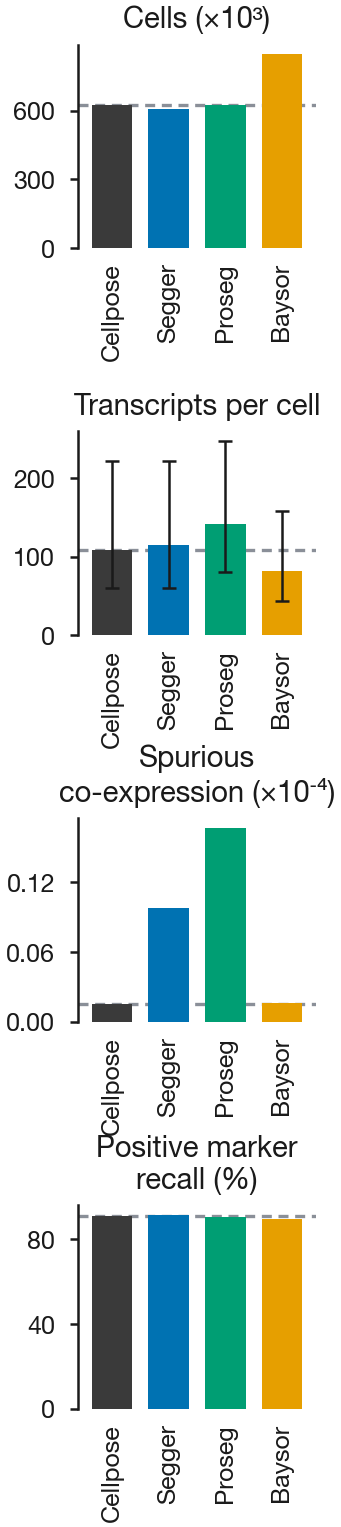

In [8]:
stats = basic.copy()
if PAPER_BENCHMARK:
    RUNS = {"cellpose": "Cellpose", "default": "Segger", "proseg": "Proseg", "baysor": "Baysor"}
    benchmark = pd.read_csv(paths["benchmark"], sep="\t").query("dataset == 'xenium_nsclc' and method in @RUNS")
    benchmark = benchmark.assign(method=benchmark["method"].map(RUNS)).pivot(index="method", columns="metric", values="value")
    stats["sce"] = benchmark["spurious_coexpression"]
    stats["pmr"] = benchmark["pct_positive_marker_recall"]

fig, axes = plt.subplots(4, 1, figsize=(26 * MM, 150 * MM), gridspec_kw={"hspace": 0.9})
sg.pl.benchmark.bars(axes[0], stats["cells"] / 1e3, title="Cells (×10³)", reference="Cellpose")
sg.pl.benchmark.bars(axes[1], stats["tx_per_cell"], stats["tx_per_cell_q1"], stats["tx_per_cell_q3"], title="Transcripts per cell", reference="Cellpose")
sg.pl.benchmark.bars(axes[2], stats["sce"] * 1e4, title="Spurious\nco-expression (×10⁻⁴)", reference="Cellpose")
sg.pl.benchmark.bars(axes[3], stats["pmr"], title="Positive marker\nrecall (%)", reference="Cellpose")
sg.pl.save_panel(fig, OUT_DIR / "panel_a")

## Panel b: morphology and masks

A cell-dense epithelial field at two zooms (200 µm, then the 100 µm grey box).
Left, the morphology image (NaK-ATPase membrane, cyan; DAPI, red) with the Cellpose outlines.
Right, Cellpose cells filled in categorical colours and each method's outlines in white.
Method outlines are concave hulls of the transcripts in the field (Delaunay triangulations pruned of long and obtuse boundary edges); for display, all outlines are rounded (closing and opening), eroded by 0.5 µm (Cellpose, 0.4 µm) to separate touching cells, and smoothed by Chaikin corner cutting.

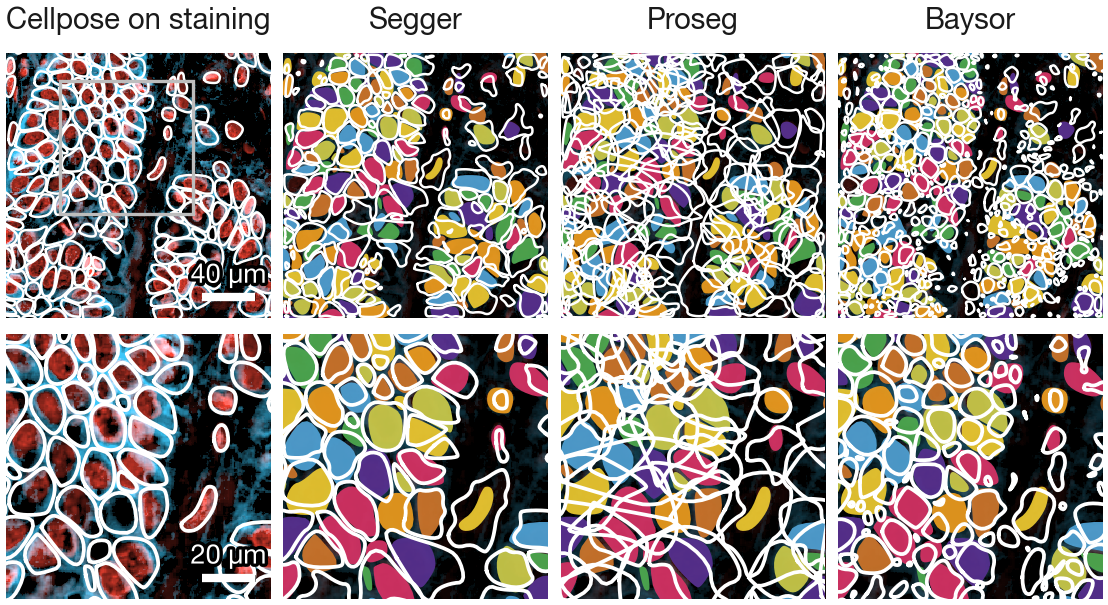

In [9]:
FIELD = (950.0, 11950.0, 1150.0, 12150.0)
ZOOM = (991.0, 11971.0, 1091.0, 12071.0)
PIXEL_SIZE = 0.425  # µm per pixel of the registered membrane image

EROSION = {"Cellpose": 0.4, "Segger": 0.5, "Proseg": 0.5, "Baysor": 0.5}  # µm, display outlines

field_tx = tx.filter(pl.col("x").is_between(FIELD[0], FIELD[2]) & pl.col("y").is_between(FIELD[1], FIELD[3]))
cellpose_polygons = sg.io.read_polygons(paths["cellpose"] / "cellpose_mask_polygons.parquet", bbox=FIELD)


def in_field(method, bbox, margin=10.0):
    """Cells of `method` with their centroid near `bbox`."""
    xy = cells[method].obsm["spatial"]
    x0, y0, x1, y1 = bbox
    keep = (xy[:, 0] > x0 - margin) & (xy[:, 0] < x1 + margin) & (xy[:, 1] > y0 - margin) & (xy[:, 1] < y1 + margin)
    return list(cells[method].obs_names[keep])


hulls = {"Cellpose": cellpose_polygons.reindex([c for c in in_field("Cellpose", FIELD) if c in cellpose_polygons.index])}
for method in METHODS[1:]:
    hulls[method] = boundaries.cell_boundaries(field_tx, method, cells=in_field(method, FIELD), kind="concave", smoothing=0)
masks = {m: h.apply(lambda g, e=EROSION[m]: boundaries.round_outline(g, erode=e)).dropna() for m, h in hulls.items()}
fill = fov.categorical_fill(masks["Cellpose"])

image = sg.io.read_morphology(paths["cellpose"] / "segmentation_image.npy", FIELD, pixel_size=PIXEL_SIZE)
membrane = fov.morphology_rgb(image[[1, 0]], [fov.MEMBRANE_CYAN, fov.DAPI_RED], percentile=[99.8, 99.7], gamma=[0.40, 0.52], background=[25, 33])

fig, axes = plt.subplots(2, 4, figsize=(120 * MM, 60 * MM), gridspec_kw={"wspace": 0.04, "hspace": 0.06})
for row, bbox in enumerate([FIELD, ZOOM]):
    fov.image(axes[row, 0], membrane, FIELD)
    fov.tile(axes[row, 0], bbox, background="black")
    fov.outlines(axes[row, 0], masks["Cellpose"].values, color="white", lw=0.6 if row == 0 else 0.9)
    for ax, method in zip(axes[row, 1:], METHODS[1:]):
        fov.image(ax, membrane * 0.35, FIELD)
        fov.tile(ax, bbox, background="black")
        fov.filled(ax, masks["Cellpose"], fill)
        fov.outlines(ax, masks[method].values, color="white", lw=0.6 if row == 0 else 0.9)
    fov.scale_bar(axes[row, 0], 40 if row == 0 else 20)
fov.box(axes[0, 0], ZOOM)
for ax, title in zip(axes[0], ["Cellpose on staining", *METHODS[1:]]):
    ax.set_title(title)
sg.pl.save_panel(fig, OUT_DIR / "panel_b")

## Panel c: boundary statistics of epithelial cells

Cell area is the area of the concave hull of each cell's transcripts, for the epithelial/cancer cells among 6,000 random cells per method (with `PAPER_SAMPLE`, the cells sampled in the paper).
Intersection over union (IoU) is taken with the Cellpose cell sharing most transcripts, counted over transcripts assigned in both segmentations, for every epithelial/cancer cell with at least ten such transcripts.
In the field of panel b, the area shared with other masks of the same method is measured on the drawn outlines grown back by their erosion, and the number of masks overlapping each Cellpose cell by more than 0.05 µm² on the drawn outlines.
Bars are medians and error bars the 25th–75th percentiles.

,area,iou,shared,per_cellpose
Cellpose,135.75,NaN,0.00,NaN
Segger,142.77,0.67,0.00,1.0
Proseg,346.32,0.54,0.77,4.0
Baysor,50.99,0.29,0.00,3.0


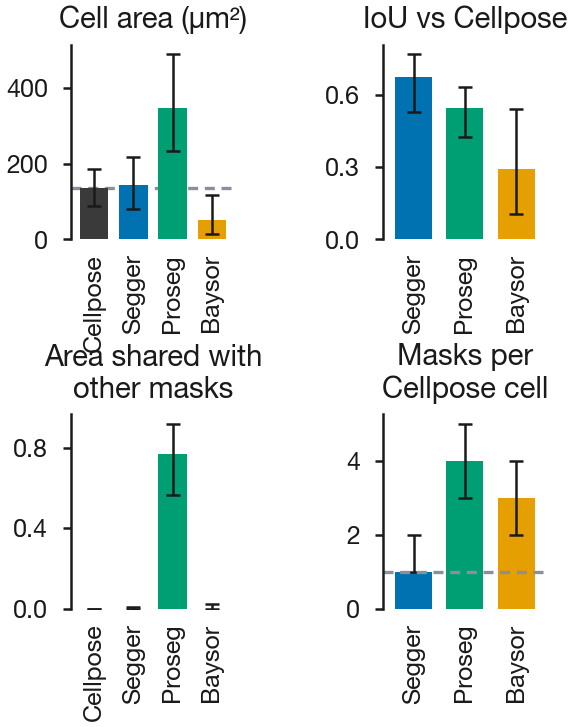

In [10]:
rng = np.random.default_rng(SEED)
epithelial = {m: adata.obs_names[adata.obs["epithelial"]] for m, adata in cells.items()}
field_masks = {m: masks[m][masks[m].index.isin(epithelial[m])] for m in METHODS}
geometry = {}
for method, adata in cells.items():
    if PAPER_SAMPLE:
        sample = pl.read_parquet(paths["area_sample"]).filter(pl.col("method") == method).get_column("cell_id")
    else:
        sample = rng.choice(np.sort(adata.obs_names), size=min(6000, adata.n_obs), replace=False)
    sample = list(set(sample) & set(epithelial[method]))
    area_hulls = boundaries.cell_boundaries(tx, method, cells=sample, kind="concave", smoothing=0, n_jobs=N_JOBS)
    geometry[method] = {"area": area_hulls.area}
    geometry[method]["shared"] = neighbors.overlap_fraction(field_masks[method].buffer(EROSION[method], join_style=1).values)
    if method != "Cellpose":
        iou = neighbors.match_reference(tx, method, "Cellpose")
        geometry[method]["iou"] = iou.loc[iou.index.intersection(epithelial[method]), "iou"]
        geometry[method]["per_cellpose"] = neighbors.masks_per_cell(field_masks["Cellpose"].values, field_masks[method].values)


def median_iqr(key, methods):
    v = {m: pd.Series(np.asarray(geometry[m][key], dtype=float)) for m in methods}
    return tuple(pd.Series({m: s.quantile(q) for m, s in v.items()}) for q in (0.5, 0.25, 0.75))


fig, axes = plt.subplots(2, 2, figsize=(52 * MM, 62 * MM), gridspec_kw={"wspace": 0.9, "hspace": 0.9})
sg.pl.benchmark.bars(axes[0, 0], *median_iqr("area", METHODS), title="Cell area (µm²)", reference="Cellpose")
sg.pl.benchmark.bars(axes[0, 1], *median_iqr("iou", METHODS[1:]), title="IoU vs Cellpose", reference=None)
sg.pl.benchmark.bars(axes[1, 0], *median_iqr("shared", METHODS), title="Area shared with\nother masks", reference=None)
sg.pl.benchmark.bars(axes[1, 1], *median_iqr("per_cellpose", METHODS[1:]), title="Masks per\nCellpose cell", reference=None)
axes[0, 1].axhline(1, color=sg.pl.style.MUTED, lw=0.8, ls=(0, (3, 2)))
axes[1, 1].axhline(1, color=sg.pl.style.MUTED, lw=0.8, ls=(0, (3, 2)))
sg.pl.save_panel(fig, OUT_DIR / "panel_c")
pd.DataFrame({k: median_iqr(k, METHODS if k in ("area", "shared") else METHODS[1:])[0] for k in ["area", "iou", "shared", "per_cellpose"]}).reindex(METHODS).round(2)

## Neighbourhood graphs

Two graphs are built identically for every segmentation and for the reference: a centroid kNN graph with up to 15 neighbours within 20 µm, and a mask-contact graph joining cells whose transcript territories touch after 1 µm dilation (transcripts painted on a 1 µm grid and grown by one pixel).

In [11]:
knn, contact, degrees = {}, {}, {}
for method, adata in cells.items():
    knn[method] = neighbors.knn_graph(adata.obsm["spatial"], n_neighbors=15, radius=20.0)
    edges = neighbors.contact_graph(tx, method, cells=list(adata.obs_names), dilation=1.0)
    contact[method] = neighbors.edge_index(edges, adata.obs_names)
    is_host = adata.obs["host"].to_numpy()
    degrees[method] = (
        neighbors.degree(knn[method], adata.n_obs)[is_host],
        neighbors.degree(contact[method], adata.n_obs)[is_host],
    )
pd.DataFrame({m: {"kNN neighbours": k.mean(), "mask contacts": c.mean(), "host cells": len(k)} for m, (k, c) in degrees.items()}).T.round(2)

,kNN neighbours,mask contacts,host cells
Cellpose,5.86,4.67,281809.0
Segger,6.29,5.10,292898.0
Proseg,6.23,7.33,288669.0
Baysor,12.83,5.32,582413.0


## Panels d and e: kNN and mask-contact graphs around one malignant epithelial cell

The same central cell for every method: the Cellpose cell at the centre of the zoom in panel b, and in each segmentation the cell holding most of its transcripts.
Field, 70 µm.

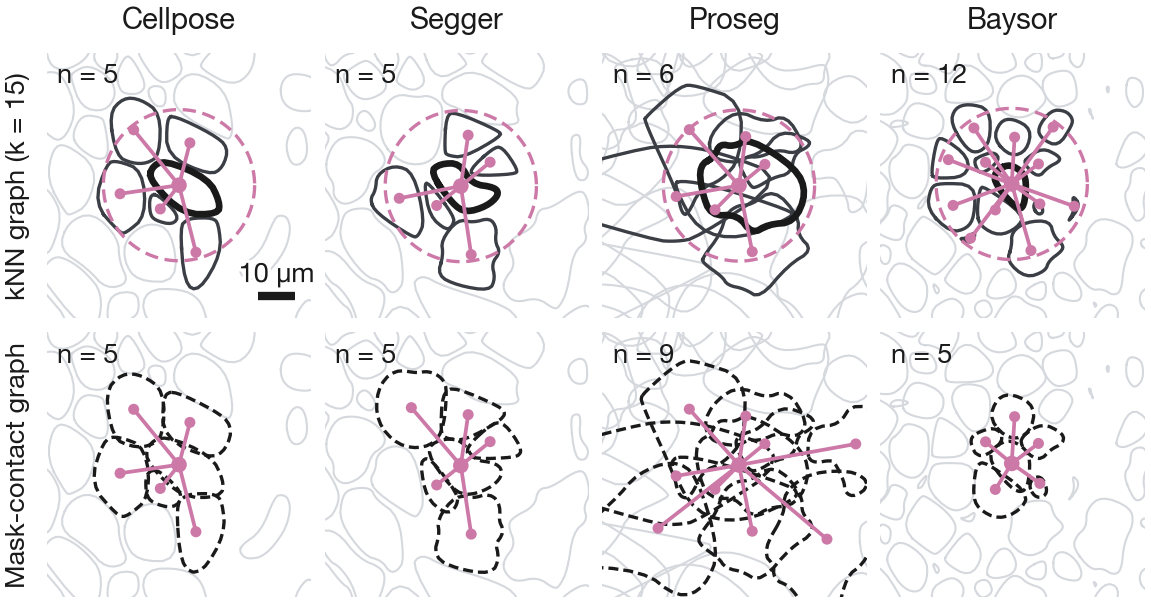

In [12]:
cp = cells["Cellpose"]
cp_xy = cp.obsm["spatial"]
is_host = cp.obs["host"].to_numpy()
focus = np.array([1041.0, 12021.0])
focal_cp = cp.obs_names[is_host][np.argmin(np.linalg.norm(cp_xy[is_host] - focus, axis=1))]
focal_tx = tx.filter(pl.col("Cellpose") == focal_cp)
center = cp_xy[cp.obs_names.get_loc(focal_cp)]
half = 35.0
ego_bbox = (center[0] - half, center[1] - half, center[0] + half, center[1] + half)


def neighbours_of(method, graph, focal):
    i = cells[method].obs_names.get_loc(focal)
    edges = graph[method]
    other = np.concatenate([edges[edges[:, 0] == i, 1], edges[edges[:, 1] == i, 0]])
    return list(cells[method].obs_names[other])


fig, axes = plt.subplots(2, 4, figsize=(120 * MM, 60 * MM), gridspec_kw={"wspace": 0.05, "hspace": 0.05})
for col, method in enumerate(METHODS):
    focal = focal_cp if method == "Cellpose" else focal_tx.get_column(method).drop_nulls().mode().sort()[0]
    names = cells[method].obs_names
    for row, (graph, kwargs) in enumerate([(knn, {"radius": 20.0}), (contact, {"dilation": 1.0})]):
        nbrs = neighbours_of(method, graph, focal)
        centroids = {c: tuple(cells[method].obsm["spatial"][names.get_loc(c)]) for c in [focal, *nbrs]}
        sg.pl.neighbors.ego_graph(axes[row, col], focal, nbrs, masks[method], centroids, ego_bbox, **kwargs)
    axes[0, col].set_title(method)
axes[0, 0].set_ylabel("kNN graph (k = 15)")
axes[1, 0].set_ylabel("Mask-contact graph")
fov.scale_bar(axes[0, 0], 10, color=sg.pl.style.INK)
sg.pl.save_panel(fig, OUT_DIR / "panel_de")

## Panel f: neighbourhood structure agreement

Per malignant epithelial cell, kNN neighbours against 1 µm mask contacts, as each method's density over cells with the per-method mean (disc) and the Cellpose mean (dashed crosshair).
Shaded bands mark excess kNN neighbours (fragmentation, Baysor) and excess mask contacts (over-expansion, Proseg).

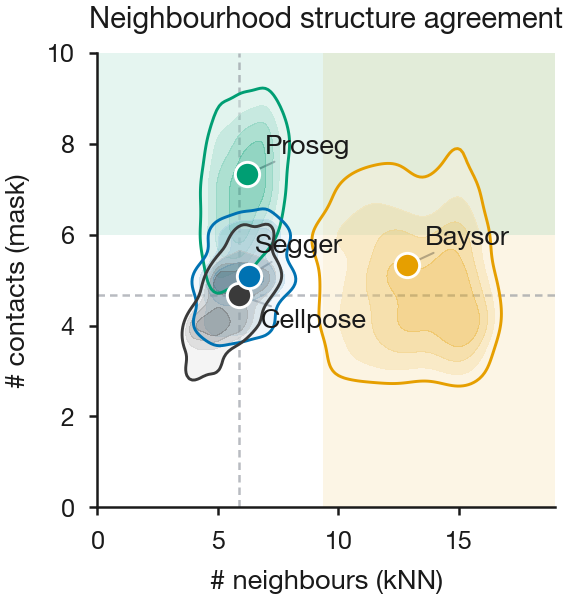

In [13]:
fig, ax = plt.subplots(figsize=(50 * MM, 50 * MM))
sg.pl.neighbors.density_clouds(ax, degrees, reference="Cellpose", fragmentation="Baysor", overexpansion="Proseg", seed=SEED)
ax.set_xlabel("# neighbours (kNN)")
ax.set_ylabel("# contacts (mask)")
ax.set_title("Neighbourhood structure agreement")
sg.pl.save_panel(fig, OUT_DIR / "panel_f")

## Comparison with the paper

Values of Fig. 4 next to the values computed above; the spurious co-expression and PMR bars of panel a are the benchmark scores and are not recomputed here.
Cellpose and Baysor, typed with the labels of the paper, match it to the precision shown.
Segger and Proseg differ slightly: from identical counts, about 0.4% of their cells receive a different CellTypist cell type than in the paper, which shifts their host and epithelial sets.
Mask contacts also depend on which cell a shared pixel is painted to, and Segger's cell areas on the order of the transcripts, which in the paper came from an unordered join.

In [14]:
PAPER = {
    "cells": {"Cellpose": 625_448, "Segger": 606_032, "Proseg": 625_151, "Baysor": 845_580},
    "transcripts per cell": {"Cellpose": 109, "Segger": 115, "Proseg": 142, "Baysor": 81},
    "kNN neighbours": {"Cellpose": 5.860075, "Segger": 6.295036, "Proseg": 6.226380, "Baysor": 12.833927},
    "mask contacts": {"Cellpose": 4.671625, "Segger": 5.110277, "Proseg": 7.344894, "Baysor": 5.322742},
    "IoU vs Cellpose": {"Segger": 0.673575, "Proseg": 0.544118, "Baysor": 0.292683},
    "cell area (µm²)": {"Cellpose": 135.75, "Segger": 142.84, "Proseg": 348.13, "Baysor": 50.99},
    "area shared with other masks": {"Cellpose": 0.0, "Segger": 0.000044, "Proseg": 0.768297, "Baysor": 0.000016},
    "masks per Cellpose cell": {"Segger": 1, "Proseg": 4, "Baysor": 3},
}
computed = {
    "cells": basic["cells"], "transcripts per cell": basic["tx_per_cell"],
    "kNN neighbours": {m: k.mean() for m, (k, _) in degrees.items()},
    "mask contacts": {m: c.mean() for m, (_, c) in degrees.items()},
    "IoU vs Cellpose": median_iqr("iou", METHODS[1:])[0],
    "cell area (µm²)": median_iqr("area", METHODS)[0],
    "area shared with other masks": median_iqr("shared", METHODS)[0],
    "masks per Cellpose cell": median_iqr("per_cellpose", METHODS[1:])[0],
}
comparison = pd.DataFrame(
    [{"metric": k, "method": m, "paper": v, "this notebook": float(pd.Series(computed[k])[m])} for k, d in PAPER.items() for m, v in d.items()]
).set_index(["metric", "method"])
comparison["difference"] = comparison["this notebook"] - comparison["paper"]
comparison.style.format({"paper": "{:.6g}", "this notebook": "{:.6g}", "difference": "{:.2g}"})

## Save as SpatialData

The transcripts with the assignment of every segmentation, the cell x gene tables and the Segger and Cellpose outlines, in one SpatialData Zarr store (element names as in `segger export spatialdata`).
Segger outlines are computed as in `segger export boundaries`; the Cellpose outlines are the reference masks.

In [15]:
outlines = {
    "Segger": boundaries.cell_boundaries(tx, "Segger", cells=list(cells["Segger"].obs_names), smoothing=0, n_jobs=N_JOBS),
    "Cellpose": sg.io.read_polygons(paths["cellpose"] / "cellpose_mask_polygons.parquet").reindex(cells["Cellpose"].obs_names).dropna(),
}
sdata = sg.io.write_spatialdata(OUT_DIR / "xenium_nsclc.zarr", tx.select("x", "y", "feature_name", *METHODS), cells, outlines, overwrite=True)
sdata

SpatialData object, with associated Zarr store: /Users/b450-admin/Desktop/Projects/Active/segger/release/segger-analysis/results/figure_4/xenium_nsclc.zarr
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 7) (2D points)
├── Shapes
│     ├── 'cell_boundaries_cellpose': GeoDataFrame shape: (487189, 1) (2D shapes)
│     └── 'cell_boundaries_segger': GeoDataFrame shape: (648316, 1) (2D shapes)
└── Tables
      ├── 'table_baysor': AnnData (1058098, 389)
      ├── 'table_cellpose': AnnData (487189, 541)
      ├── 'table_proseg': AnnData (647348, 389)
      └── 'table_segger': AnnData (648316, 389)
with coordinate systems:
    ▸ 'global', with elements:
        transcripts (Points), cell_boundaries_cellpose (Shapes), cell_boundaries_segger (Shapes)

## Software versions

In [16]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # deprecation notices raised while reading package versions
    display(sc.logging.print_header())

Package,Version
spatialdata,0.4.0
pandas,2.2.3
anndata,0.11.4
matplotlib,3.10.1
numpy,2.2.5
polars,1.44.2
scanpy,1.11.4
geopandas,1.0.1
Component,Info
Python,"3.11.15 (main, May 8 2026, 18:24:56) [Clang 22.1.3 ]"
